Assignment 1 - Tehran Housing Analysis

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [96]:
df = pd.read_csv("Data.csv")
df.head(10)

,total_value,neighborhood,area,year,deposit,rent,elavator,parking,warehouse
0,2.000900e+09,ولنجک,270,1399,2.000000e+09,30000000.0,1,1,1
1,2.001200e+08,کوی فردوس,70,1387,2.000000e+08,4000000.0,0,1,1
2,3.502550e+08,پونک,120,1395,3.500000e+08,8500000.0,1,1,1
3,2.003000e+08,هروی,110,1395,2.000000e+08,10000000.0,1,1,1
4,2.001800e+08,پونک,80,1387,2.000000e+08,6000000.0,1,1,1
5,3.000000e+08,جنت‌آباد جنوبی,60,1395,3.000000e+08,0.0,1,1,1
6,6.021000e+07,جنت‌آباد جنوبی,95,1386,6.000000e+07,7000000.0,0,1,1
7,2.001800e+08,ستارخان,100,1399,2.000000e+08,6000000.0,1,1,1
8,4.003600e+08,سعادت‌آباد,180,1387,4.000000e+08,12000000.0,1,1,1
9,2.800000e+09,سعادت‌آباد,250,1399,2.800000e+09,0.0,1,1,1


In [97]:
df.shape

(12383, 9)

In [98]:
df.columns

Index(['total_value', 'neighborhood', 'area', 'year', 'deposit', 'rent',
       'elavator', 'parking', 'warehouse'],
      dtype='str')

In [99]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12383 entries, 0 to 12382
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   total_value   12383 non-null  float64
 1   neighborhood  12383 non-null  str    
 2   area          12383 non-null  int64  
 3   year          12383 non-null  int64  
 4   deposit       12383 non-null  float64
 5   rent          12383 non-null  float64
 6   elavator      12383 non-null  int64  
 7   parking       12383 non-null  int64  
 8   warehouse     12383 non-null  int64  
dtypes: float64(3), int64(5), str(1)
memory usage: 870.8 KB


Initial observations

The dataset contains 12383 rows and 9 columns.
The likely target variable is value.
Some columns are numerical, while some are textual.
The neighborhood information is stored as text and may require encoding later.
Some columns may require cleaning before preprocessing.

Data Cleaning and Validation

In [100]:
df_clean1 = df.copy() #for not destroying the real data

In [101]:
missing_summary = df_clean1.isna().sum().sort_values(ascending=False)
duplicate_count = df_clean1.duplicated().sum()

print("Missing values per column:")
print(missing_summary)

print("\nNumber of duplicated rows:", duplicate_count)

Missing values per column:
total_value     0
neighborhood    0
area            0
year            0
deposit         0
rent            0
elavator        0
parking         0
warehouse       0
dtype: int64

Number of duplicated rows: 0


In [102]:
df_clean1.columns = df_clean1.columns.str.strip()     #checking not differences between "نیاوران" and " نیاوران "

object_cols = df_clean1.select_dtypes(include="object").columns

for col in object_cols:
    df_clean1[col] = df_clean1[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

df_clean1.columns

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18848\2452266820.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df_clean1.select_dtypes(include="object").columns


Index(['total_value', 'neighborhood', 'area', 'year', 'deposit', 'rent',
       'elavator', 'parking', 'warehouse'],
      dtype='str')

In [103]:
value_col = "total_value"
area_col = "area"
year_col = "year"
deposit_col = "deposit"
rent_col = "rent"
neighborhood_col = "neighborhood"
parking_col = "parking"
elavator_col = "elavator"

def to_numeric_safely(series):
    return pd.to_numeric(series, errors="coerce")

cleaning_report = {
    "missing_values_total": int(df_clean1.isna().sum().sum()),
    "duplicate_rows": int(df_clean1.duplicated().sum())
}

# total_value (my goal is prediction the value of house so value <= 0 is invalid )
value_num = to_numeric_safely(df_clean1[value_col])
cleaning_report["invalid_total_value"] = int((value_num <= 0).sum())
cleaning_report["non_numeric_total_value"] = int(value_num.isna().sum())

# area (bigger than 20m)
area_num = to_numeric_safely(df_clean1[area_col])
cleaning_report["invalid_area"] = int((area_num <= 20).sum())
cleaning_report["non_numeric_area"] = int(area_num.isna().sum())

# year
year_num = to_numeric_safely(df_clean1[year_col])
cleaning_report["invalid_year"] = int((year_num <= 0).sum())
cleaning_report["non_numeric_year"] = int(year_num.isna().sum())

# deposit
deposit_num = to_numeric_safely(df_clean1[deposit_col])
cleaning_report["invalid_deposit"] = int((deposit_num < 0).sum())
cleaning_report["non_numeric_deposit"] = int(deposit_num.isna().sum())

# rent
rent_num = to_numeric_safely(df_clean1[rent_col])
cleaning_report["invalid_rent"] = int((rent_num < 0).sum())
cleaning_report["non_numeric_rent"] = int(rent_num.isna().sum())

# parking
parking_num = to_numeric_safely(df_clean1[parking_col])
cleaning_report["invalid_parking"] = int((parking_num < 0).sum())
cleaning_report["non_numeric_parking"] = int(parking_num.isna().sum())

# elavator
elavator_num = to_numeric_safely(df_clean1[elavator_col])
cleaning_report["invalid_elavator"] = int((elavator_num < 0).sum())
cleaning_report["non_numeric_elavator"] = int(elavator_num.isna().sum())

import pandas as pd 
pd.DataFrame([cleaning_report])

,missing_values_total,duplicate_rows,invalid_total_value,non_numeric_total_value,invalid_area,non_numeric_area,invalid_year,non_numeric_year,invalid_deposit,non_numeric_deposit,invalid_rent,non_numeric_rent,invalid_parking,non_numeric_parking,invalid_elavator,non_numeric_elavator
0,0,0,1536,0,8,0,0,0,0,0,0,0,0,0,0,0


In [104]:
df_clean1 = df_clean1[(df_clean1["total_value"] > 0) & (df_clean1["total_value"].notna()) & (df_clean1["area"] > 20)] #removing homes that is invalid

In [105]:
print("Shape:", df_clean1.shape)                                        #remove checking
print("Zero or negative values:", (df_clean1["total_value"] <= 0).sum())
print("Small houses:", (df_clean1["area"] <= 20).sum())

Shape: (10841, 9)
Zero or negative values: 0
Small houses: 0


In [106]:
usd_to_toman = 20000 #in 1399
df_clean1["total_value"] = df_clean1["total_value"] / usd_to_toman  #replacing values by dollar

In [107]:
df_clean1["total_value"].describe()

count    1.084100e+04
mean     2.831252e+04
std      4.627212e+04
min      1.504500e-03
25%      8.000000e+03
50%      1.506000e+04
75%      3.007500e+04
max      2.500007e+06
Name: total_value, dtype: float64

In [108]:
df_clean1 = df_clean1[(df_clean1["total_value"] > 1000)]       #cleaning very cheap houses
df_clean1.describe()

,total_value,area,year,deposit,rent,elavator,parking,warehouse
count,1.077200e+04,10772.000000,10772.000000,1.077200e+04,1.077200e+04,10772.000000,10772.000000,10772.000000
mean,2.849199e+04,170.155496,1391.392128,5.692063e+08,2.111676e+07,0.790754,0.875418,0.999814
std,4.636554e+04,3194.241741,6.683236,9.272112e+08,5.117693e+08,0.406789,0.330260,0.013625
min,1.000450e+03,30.000000,1363.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,8.500000e+03,80.000000,1387.000000,1.700000e+08,0.000000e+00,1.000000,1.000000,1.000000
50%,1.600000e+04,110.000000,1393.000000,3.200000e+08,3.000000e+06,1.000000,1.000000,1.000000
75%,3.056250e+04,150.000000,1397.000000,6.100000e+08,1.000000e+07,1.000000,1.000000,1.000000
max,2.500007e+06,300000.000000,1399.000000,5.000000e+10,3.500000e+10,1.000000,1.000000,1.000000


- Checking for missing values
- Checking for duplicate rows
- Removing extra spaces from textual columns
- Validating numerical columns such as `total_value`, `area`, `year`, `deposit`, and `rent`
- Removing records with invalid target values
- Removing unrealistically small properties
- Converting `total_value` to USD using an approximate exchange rate
- Removing extremely low housing values that are likely unrealistic for this analysis

Preprocessing

In [109]:
df_preprocessed2 = df_clean1.copy()

In [110]:
df_preprocessed2["price_per_meter"] = df_preprocessed2["total_value"] / df_preprocessed2["area"]
neighborhood_mean = df_preprocessed2.groupby("neighborhood")["price_per_meter"].mean()
df_preprocessed2["neighborhood_encoded"] = df_preprocessed2["neighborhood"].map(neighborhood_mean)

In [111]:
df_preprocessed2.head()

,total_value,neighborhood,area,year,deposit,rent,elavator,parking,warehouse,price_per_meter,neighborhood_encoded
0,100045.00,ولنجک,270,1399,2.000000e+09,30000000.0,1,1,1,370.537037,273.385324
1,10006.00,کوی فردوس,70,1387,2.000000e+08,4000000.0,0,1,1,142.942857,166.804928
2,17512.75,پونک,120,1395,3.500000e+08,8500000.0,1,1,1,145.939583,163.524008
3,10015.00,هروی,110,1395,2.000000e+08,10000000.0,1,1,1,91.045455,224.780976
4,10009.00,پونک,80,1387,2.000000e+08,6000000.0,1,1,1,125.112500,163.524008


In [112]:
df_preprocessed2["price_per_meter"].describe()

count    10772.000000
mean       200.828469
std        504.743530
min          0.075090
25%         85.971429
50%        150.180000
75%        266.670417
max      50000.135000
Name: price_per_meter, dtype: float64

In [113]:
#removing bad data base on price per meter.
Q1 = df_preprocessed2["price_per_meter"].quantile(0.25)
Q3 = df_preprocessed2["price_per_meter"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# not negative
lower = 20

df_preprocessed2 = df_preprocessed2[
    (df_preprocessed2["price_per_meter"] >= lower) &
    (df_preprocessed2["price_per_meter"] <= upper)
]

df_preprocessed2.shape

(10307, 11)

Neighborhood Encoding Based on Price per Meter

A new feature called `price_per_meter` was created by dividing the total property value by the area.

Then the average price per square meter was calculated for each neighborhood. Since neighborhood is a categorical text feature it was encoded by replacing each neighborhood name with its average price per meter.


Feature Engineering (create new features)

In [114]:
df_features = df_preprocessed2.copy()

Age was calculated as:
Age = 1399 - Year
This allows the model to better understand how old a property is, which is often more relevant than the raw construction year.

In [115]:
df_features["age"] = 1399 - df_features["year"]
df_features.head(10)

,total_value,neighborhood,area,year,deposit,rent,elavator,parking,warehouse,price_per_meter,neighborhood_encoded,age
0,100045.00,ولنجک,270,1399,2.000000e+09,30000000.0,1,1,1,370.537037,273.385324,0
1,10006.00,کوی فردوس,70,1387,2.000000e+08,4000000.0,0,1,1,142.942857,166.804928,12
2,17512.75,پونک,120,1395,3.500000e+08,8500000.0,1,1,1,145.939583,163.524008,4
3,10015.00,هروی,110,1395,2.000000e+08,10000000.0,1,1,1,91.045455,224.780976,4
4,10009.00,پونک,80,1387,2.000000e+08,6000000.0,1,1,1,125.112500,163.524008,12
5,15000.00,جنت‌آباد جنوبی,60,1395,3.000000e+08,0.0,1,1,1,250.000000,164.449834,4
6,3010.50,جنت‌آباد جنوبی,95,1386,6.000000e+07,7000000.0,0,1,1,31.689474,164.449834,13
7,10009.00,ستارخان,100,1399,2.000000e+08,6000000.0,1,1,1,100.090000,154.250644,0
8,20018.00,سعادت‌آباد,180,1387,4.000000e+08,12000000.0,1,1,1,111.211111,251.970401,12
10,3504.20,تهرانپارس شرقی,70,1390,7.000000e+07,2800000.0,1,0,1,50.060000,109.794283,9


A new feature was created to represent the overall quality of a property based on available amenities.

The features considered were:
- parking
- elevator
- warehouse

These binary features were combined into a single score:

- 0 → no amenities → quality = 0
- 1 → one amenity → quality = 1
- 2 → two amenities → quality = 2
- 3 → all amenities → quality = 3

In [116]:
df_features["quality_score"] = (
    df_features["parking"] +
    df_features["elavator"] +
    df_features["warehouse"]
)
df_features.head(5)

,total_value,neighborhood,area,year,deposit,rent,elavator,parking,warehouse,price_per_meter,neighborhood_encoded,age,quality_score
0,100045.00,ولنجک,270,1399,2.000000e+09,30000000.0,1,1,1,370.537037,273.385324,0,3
1,10006.00,کوی فردوس,70,1387,2.000000e+08,4000000.0,0,1,1,142.942857,166.804928,12,2
2,17512.75,پونک,120,1395,3.500000e+08,8500000.0,1,1,1,145.939583,163.524008,4,3
3,10015.00,هروی,110,1395,2.000000e+08,10000000.0,1,1,1,91.045455,224.780976,4,3
4,10009.00,پونک,80,1387,2.000000e+08,6000000.0,1,1,1,125.112500,163.524008,12,3


A binary feature was created to indicate whether a property is more expensive than the average of its neighborhood.

In [117]:
df_features["compare_to_mean"] = (df_features["price_per_meter"] > df_features["neighborhood_encoded"]
).astype(int)
df_features.head(5)

,total_value,neighborhood,area,year,deposit,rent,elavator,parking,warehouse,price_per_meter,neighborhood_encoded,age,quality_score,compare_to_mean
0,100045.00,ولنجک,270,1399,2.000000e+09,30000000.0,1,1,1,370.537037,273.385324,0,3,1
1,10006.00,کوی فردوس,70,1387,2.000000e+08,4000000.0,0,1,1,142.942857,166.804928,12,2,0
2,17512.75,پونک,120,1395,3.500000e+08,8500000.0,1,1,1,145.939583,163.524008,4,3,0
3,10015.00,هروی,110,1395,2.000000e+08,10000000.0,1,1,1,91.045455,224.780976,4,3,0
4,10009.00,پونک,80,1387,2.000000e+08,6000000.0,1,1,1,125.112500,163.524008,12,3,0


Neighborhoods were grouped into four price levels based on their average price per meter using quartiles. (0 to 3)

In [118]:
# Calculate quartile-based categories for neighborhoods based on average price per meter
df_features["neighborhood_price_category"] = pd.qcut(
    df_features["neighborhood_encoded"],
    q=4,
    labels=[0, 1, 2, 3]
)

# Convert category labels to integer
df_features["neighborhood_price_category"] = df_features["neighborhood_price_category"].astype(int)

df_features.head()

,total_value,neighborhood,area,year,deposit,rent,elavator,parking,warehouse,price_per_meter,neighborhood_encoded,age,quality_score,compare_to_mean,neighborhood_price_category
0,100045.00,ولنجک,270,1399,2.000000e+09,30000000.0,1,1,1,370.537037,273.385324,0,3,1,3
1,10006.00,کوی فردوس,70,1387,2.000000e+08,4000000.0,0,1,1,142.942857,166.804928,12,2,0,1
2,17512.75,پونک,120,1395,3.500000e+08,8500000.0,1,1,1,145.939583,163.524008,4,3,0,1
3,10015.00,هروی,110,1395,2.000000e+08,10000000.0,1,1,1,91.045455,224.780976,4,3,0,2
4,10009.00,پونک,80,1387,2.000000e+08,6000000.0,1,1,1,125.112500,163.524008,12,3,0,1


this feature is showing a basic formula for predicting value from rent (rent for 1 year == 5% of total value).

In [119]:
rial_to_toman = 0.1
df_features["value_from_rent_prediction"] = (((df_features["rent"]*12)/usd_to_toman)*20*rial_to_toman)
df_features.head()

,total_value,neighborhood,area,year,deposit,rent,elavator,parking,warehouse,price_per_meter,neighborhood_encoded,age,quality_score,compare_to_mean,neighborhood_price_category,value_from_rent_prediction
0,100045.00,ولنجک,270,1399,2.000000e+09,30000000.0,1,1,1,370.537037,273.385324,0,3,1,3,36000.0
1,10006.00,کوی فردوس,70,1387,2.000000e+08,4000000.0,0,1,1,142.942857,166.804928,12,2,0,1,4800.0
2,17512.75,پونک,120,1395,3.500000e+08,8500000.0,1,1,1,145.939583,163.524008,4,3,0,1,10200.0
3,10015.00,هروی,110,1395,2.000000e+08,10000000.0,1,1,1,91.045455,224.780976,4,3,0,2,12000.0
4,10009.00,پونک,80,1387,2.000000e+08,6000000.0,1,1,1,125.112500,163.524008,12,3,0,1,7200.0


Visualization

In [120]:
df_viz = df_features.copy()

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.figure(figsize=(6, 4))

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

This plot shows the distribution of property prices per square meter.

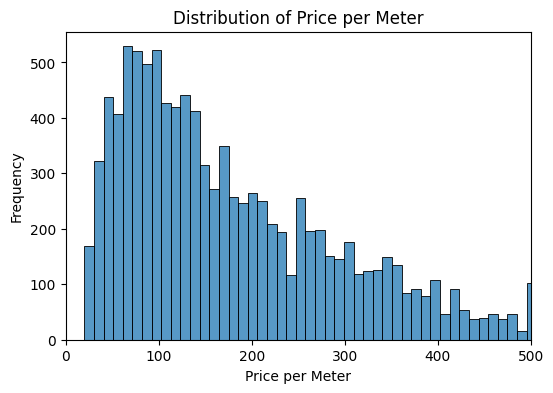

In [121]:
plt.figure(figsize=(6, 4))
sns.histplot(df_viz["price_per_meter"], bins=50)

plt.title("Distribution of Price per Meter")
plt.xlabel("Price per Meter")
plt.ylabel("Frequency")
plt.xlim(0, df_viz["price_per_meter"].quantile(0.99))
plt.show()

A positive relationship is observed between price per meter and total value.  
Higher-priced neighborhoods tend to cluster in the upper ranges, indicating the strong influence of location on property value.

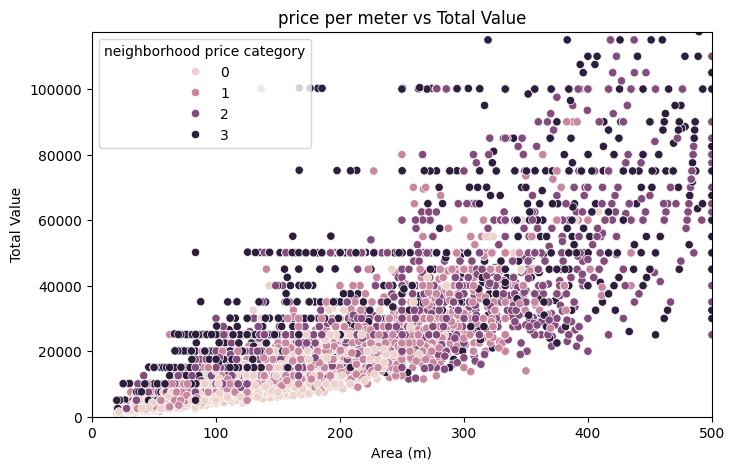

In [122]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_viz,
    x="price_per_meter",
    y="total_value",
    hue="neighborhood_price_category"
)

plt.title("price per meter vs Total Value")
plt.xlabel("Area (m)")
plt.ylabel("Total Value")
plt.xlim(0, df_viz["price_per_meter"].quantile(0.99))
plt.ylim(0, df_viz["total_value"].quantile(0.99))
plt.legend(title="neighborhood price category")
plt.show()

This chart shows the average price per meter for properties that have each amenity.

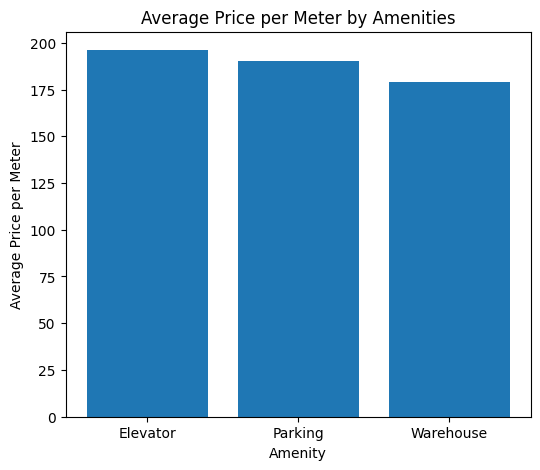

In [123]:
amenities_avg_value = {
    "Elevator": df_viz[df_viz["elavator"] == 1]["price_per_meter"].mean(),
    "Parking": df_viz[df_viz["parking"] == 1]["price_per_meter"].mean(),
    "Warehouse": df_viz[df_viz["warehouse"] == 1]["price_per_meter"].mean()
}

plt.figure(figsize=(6, 5))
plt.bar(amenities_avg_value.keys(), amenities_avg_value.values())

plt.title("Average Price per Meter by Amenities")
plt.xlabel("Amenity")
plt.ylabel("Average Price per Meter")

plt.show()

A new feature was created by combining `quality_score` and `neighborhood_price_category` to capture the joint effect of property quality and location. 

The pie chart visualizes the distribution of the most frequent combinations (top 8), while grouping the remaining categories into "Others" for better readability.

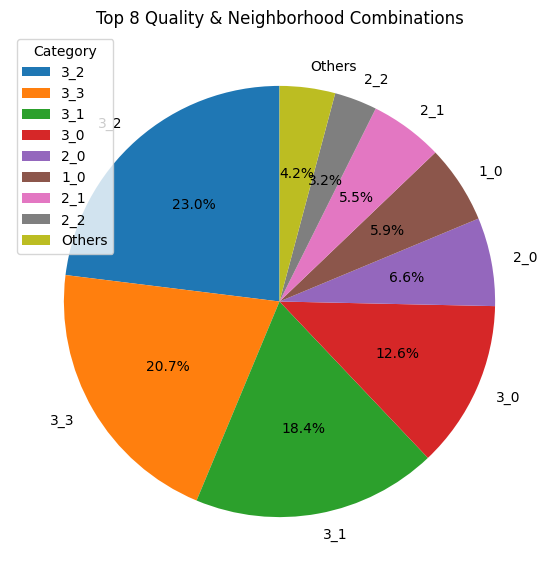

In [124]:
df_viz["quality_neighborhood"] = (
    df_viz["quality_score"].astype(str) + "_" +
    df_viz["neighborhood_price_category"].astype(str)
)
combo_counts = df_viz["quality_neighborhood"].value_counts()

top8 = combo_counts.head(8)
others = combo_counts.iloc[8:].sum()

top8["Others"] = others

plt.figure(figsize=(7, 7))

plt.pie(
    top8,
    labels=top8.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 8 Quality & Neighborhood Combinations")
plt.legend(title="Category")

plt.show()

This chart compares the average total value across different quality scores and neighborhood price categories, showing how property quality and location jointly affect housing prices.

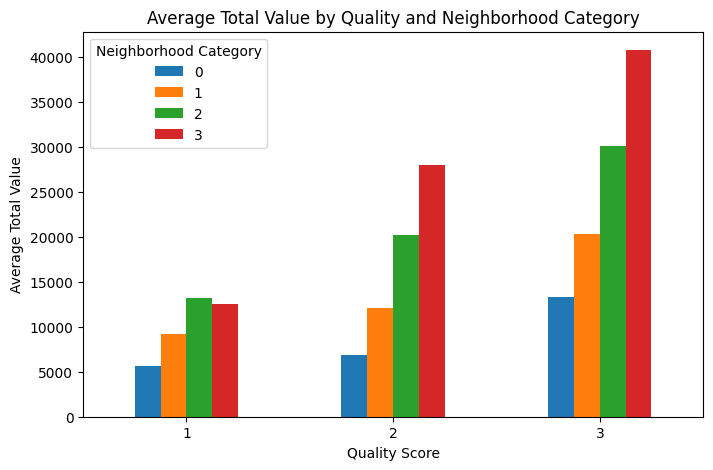

In [125]:
grouped_data = df_viz.groupby(["quality_score", "neighborhood_price_category"])["total_value"].mean().unstack()

grouped_data.plot(kind="bar", figsize=(8, 5))

plt.title("Average Total Value by Quality and Neighborhood Category")
plt.xlabel("Quality Score")
plt.ylabel("Average Total Value")
plt.legend(title="Neighborhood Category")
plt.xticks(rotation=0)

plt.show()

This line chart shows how average price per meter changes with deposit value.

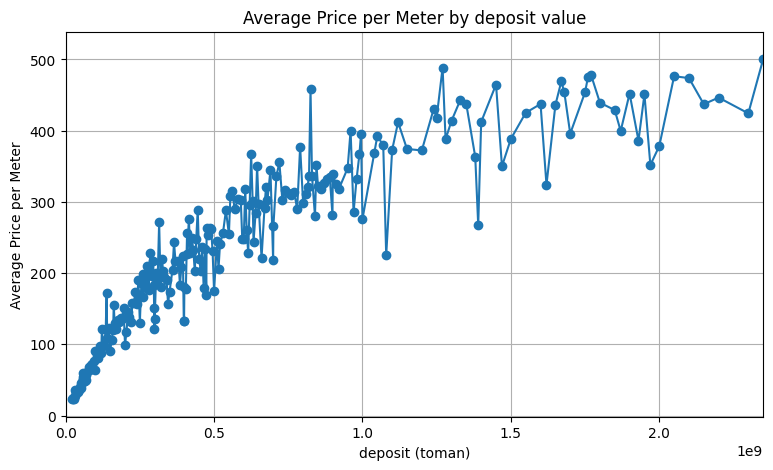

In [126]:
age_price = df_viz.groupby("deposit")["price_per_meter"].mean()

plt.figure(figsize=(9, 5))
plt.plot(age_price.index, age_price.values, marker="o")

plt.title("Average Price per Meter by deposit value")
plt.xlabel("deposit (toman)")
plt.ylabel("Average Price per Meter")
plt.xlim(0, df_viz["deposit"].quantile(0.99))
plt.grid(True)
plt.show()

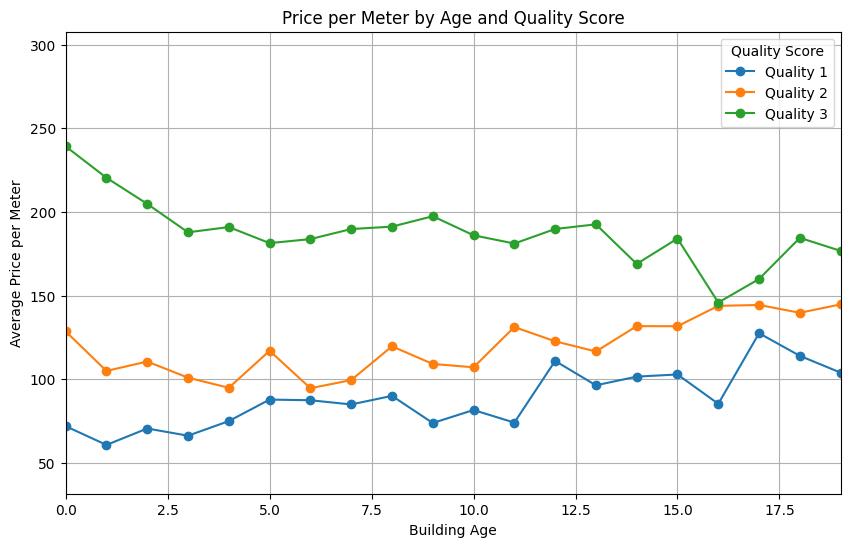

In [127]:
age_quality_price = df_viz.groupby(["age", "quality_score"])["price_per_meter"].mean().unstack()

plt.figure(figsize=(10, 6))

for col in age_quality_price.columns:
    plt.plot(age_quality_price.index, age_quality_price[col], marker="o", label=f"Quality {col}")

plt.title("Price per Meter by Age and Quality Score")
plt.xlabel("Building Age")
plt.ylabel("Average Price per Meter")
plt.xlim(0, df_viz["age"].quantile(0.95))
plt.legend(title="Quality Score")
plt.grid(True)
plt.show()

This interactive scatter plot shows the relationship between area and price per meter.  
Hovering over each point reveals additional details such as age, total_value, and compare to min, allowing deeper inspection of individual properties.

In [128]:
fig = px.scatter(
    df_viz,
    x="area",
    y="price_per_meter",
    color="neighborhood_price_category",
    size="quality_score",
    hover_data=["age", "total_value", "compare_to_mean"],
    title="Interactive Scatter Plot: Area vs Price per Meter"
)

fig.update_layout(
    xaxis_title="Area (m²)",
    yaxis_title="Price per Meter",
    legend_title="Neighborhood Price Category"
)

fig.update_xaxes(range=[0, df_viz["area"].quantile(0.99)])
fig.update_yaxes(range=[0, df_viz["price_per_meter"].quantile(0.99)])

fig.show()

Three plots were used to compare the relationship between price per meter and total value under different transformations.

The original plot shows a non-linear pattern, while the square root and logarithmic transformations reduce this non-linearity. The square root transformation provides a more linear relationship, confirming that the original relationship was approximately quadratic.

In [129]:
import numpy as np

df_viz["sqrt_total_value"] = np.sqrt(df_viz["total_value"])
df_viz["log_total_value"] = np.log(df_viz["total_value"] + 1)
df_viz.head()

,total_value,neighborhood,area,year,deposit,rent,elavator,parking,warehouse,price_per_meter,neighborhood_encoded,age,quality_score,compare_to_mean,neighborhood_price_category,value_from_rent_prediction,quality_neighborhood,sqrt_total_value,log_total_value
0,100045.00,ولنجک,270,1399,2.000000e+09,30000000.0,1,1,1,370.537037,273.385324,0,3,1,3,36000.0,3_3,316.298909,11.513385
1,10006.00,کوی فردوس,70,1387,2.000000e+08,4000000.0,0,1,1,142.942857,166.804928,12,2,0,1,4800.0,2_1,100.029996,9.211040
2,17512.75,پونک,120,1395,3.500000e+08,8500000.0,1,1,1,145.939583,163.524008,4,3,0,1,10200.0,3_1,132.335747,9.770742
3,10015.00,هروی,110,1395,2.000000e+08,10000000.0,1,1,1,91.045455,224.780976,4,3,0,2,12000.0,3_2,100.074972,9.211939
4,10009.00,پونک,80,1387,2.000000e+08,6000000.0,1,1,1,125.112500,163.524008,12,3,0,1,7200.0,3_1,100.044990,9.211340


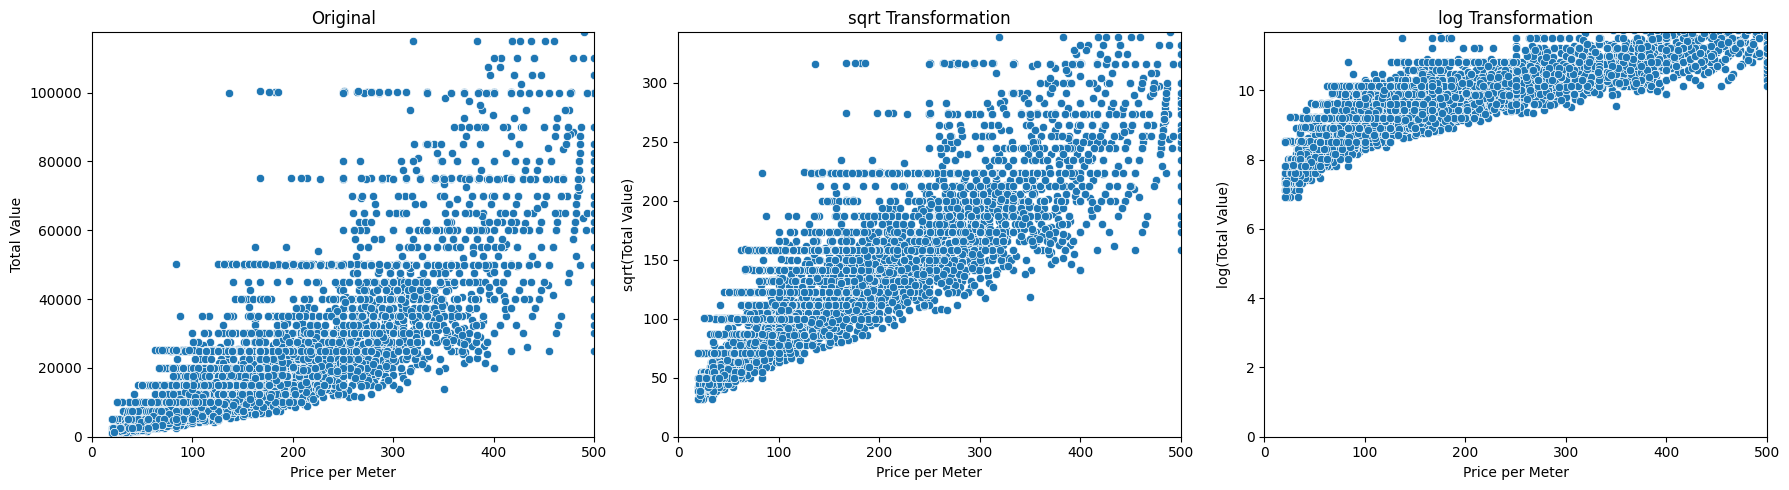

In [130]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#  Original
sns.scatterplot(
    data=df_viz,
    x="price_per_meter",
    y="total_value",
    ax=axes[0]
)
axes[0].set_title("Original")
axes[0].set_xlabel("Price per Meter")
axes[0].set_ylabel("Total Value")
axes[0].set_xlim(0, df_viz["price_per_meter"].quantile(0.99))
axes[0].set_ylim(0, df_viz["total_value"].quantile(0.99))

#  sqrt
sns.scatterplot(
    data=df_viz,
    x="price_per_meter",
    y="sqrt_total_value",
    ax=axes[1]
)
axes[1].set_title("sqrt Transformation")
axes[1].set_xlabel("Price per Meter")
axes[1].set_ylabel("sqrt(Total Value)")
axes[1].set_xlim(0, df_viz["price_per_meter"].quantile(0.99))
axes[1].set_ylim(0, df_viz["sqrt_total_value"].quantile(0.99))

#  log
sns.scatterplot(
    data=df_viz,
    x="price_per_meter",
    y="log_total_value",
    ax=axes[2]
)
axes[2].set_title("log Transformation")
axes[2].set_xlabel("Price per Meter")
axes[2].set_ylabel("log(Total Value)")
axes[2].set_xlim(0, df_viz["price_per_meter"].quantile(0.99))
axes[2].set_ylim(0, df_viz["log_total_value"].quantile(0.99))

plt.tight_layout()
plt.show()

A squared version of the deposit feature was created to explore potential non-linear relationships between deposit and price per meter.

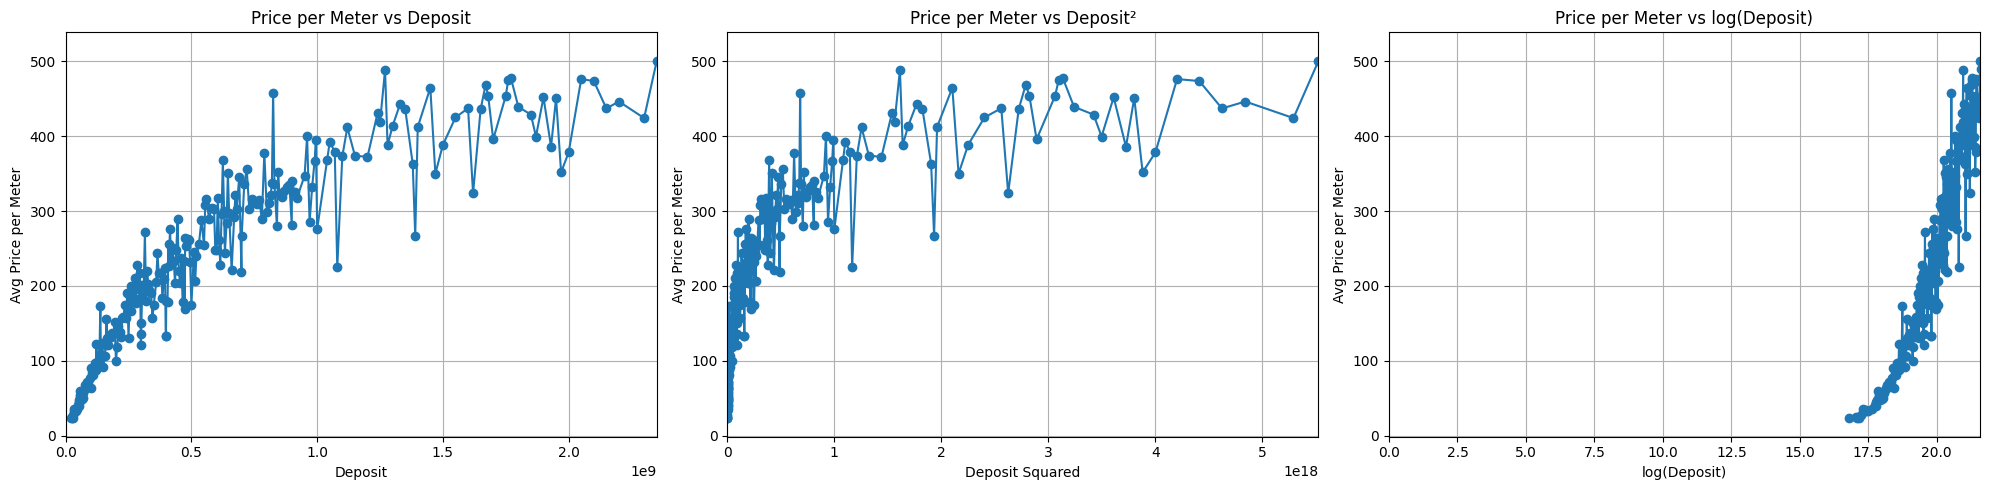

In [131]:
df_viz["deposit_squared"] = df_viz["deposit"] ** 2
df_viz["log_deposit"] = np.log(df_viz["deposit"] + 1)

dep_price = df_viz.groupby("deposit")["price_per_meter"].mean()
dep_sq_price = df_viz.groupby("deposit_squared")["price_per_meter"].mean()
dep_log_price = df_viz.groupby("log_deposit")["price_per_meter"].mean()


fig, axes = plt.subplots(1, 3, figsize=(20, 5))

#  Original
axes[0].plot(dep_price.index, dep_price.values, marker="o")
axes[0].set_title("Price per Meter vs Deposit")
axes[0].set_xlabel("Deposit")
axes[0].set_ylabel("Avg Price per Meter")
axes[0].set_xlim(0, df_viz["deposit"].quantile(0.99))
axes[0].grid(True)

#  Square
axes[1].plot(dep_sq_price.index, dep_sq_price.values, marker="o")
axes[1].set_title("Price per Meter vs Deposit²")
axes[1].set_xlabel("Deposit Squared")
axes[1].set_ylabel("Avg Price per Meter")
axes[1].set_xlim(0, df_viz["deposit_squared"].quantile(0.99))
axes[1].grid(True)

#  Log
axes[2].plot(dep_log_price.index, dep_log_price.values, marker="o")
axes[2].set_title("Price per Meter vs log(Deposit)")
axes[2].set_xlabel("log(Deposit)")
axes[2].set_ylabel("Avg Price per Meter")
axes[2].set_xlim(0, df_viz["log_deposit"].quantile(0.99))
axes[2].grid(True)

plt.tight_layout()
plt.show()

Three transformations of the deposit feature were compared: original, squared, and logarithmic.  
The log transformation reduces skewness, while the squared transformation highlights non-linear effects, helping to better understand the relationship with price per meter.

MI

In [132]:
df_mi = df_viz.select_dtypes(include=["int64", "float64", "int32", "float32"]).copy()
from sklearn.feature_selection import mutual_info_regression

X = df_mi.drop("total_value", axis=1)
y = df_mi["total_value"]

mi_scores = mutual_info_regression(X, y, random_state=42)

mi_result = pd.Series(mi_scores, index=X.columns)
mi_result = mi_result.sort_values(ascending=False)

mi_result

sqrt_total_value               6.149947
log_total_value                6.059193
deposit                        3.848529
deposit_squared                3.837691
log_deposit                    3.834639
price_per_meter                2.716558
value_from_rent_prediction     2.361084
rent                           2.356067
area                           0.814559
neighborhood_encoded           0.772892
neighborhood_price_category    0.471418
compare_to_mean                0.450957
quality_score                  0.205509
parking                        0.141393
elavator                       0.134653
year                           0.105380
age                            0.101760
warehouse                      0.002127
dtype: float64

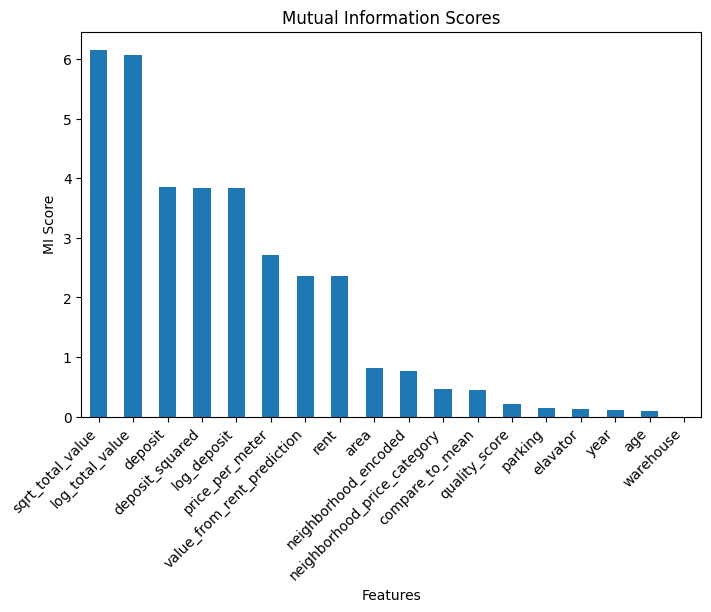

In [133]:
plt.figure(figsize=(8, 5))

mi_result.plot(kind="bar")

plt.title("Mutual Information Scores")
plt.xlabel("Features")
plt.ylabel("MI Score")
plt.xticks(rotation=45, ha="right")

plt.show()

The Mutual Information results show that features such as `deposit`, `price_per_meter`, and `rent` have the strongest relationship with the target variable.

Features like `area` and `neighborhood_encoded` have moderate importance, while features such as `parking`, `elevator`, and `warehouse` show little to no impact.

It is also observed that derived features like `sqrt_total_value` and `log_total_value` have very high scores due to their direct dependency on the target variable, and therefore should not be used in modeling to avoid data leakage.

In [134]:
df_model = df_viz.drop([
    "sqrt_total_value",
    "log_total_value",
    "elavator",
    "parking",
    "age",
    "year",
    "warehouse",
    "neighborhood"
], axis=1)
df_model.head()

,total_value,area,deposit,rent,price_per_meter,neighborhood_encoded,quality_score,compare_to_mean,neighborhood_price_category,value_from_rent_prediction,quality_neighborhood,deposit_squared,log_deposit
0,100045.00,270,2.000000e+09,30000000.0,370.537037,273.385324,3,1,3,36000.0,3_3,4.000000e+18,21.416413
1,10006.00,70,2.000000e+08,4000000.0,142.942857,166.804928,2,0,1,4800.0,2_1,4.000000e+16,19.113828
2,17512.75,120,3.500000e+08,8500000.0,145.939583,163.524008,3,0,1,10200.0,3_1,1.225000e+17,19.673444
3,10015.00,110,2.000000e+08,10000000.0,91.045455,224.780976,3,0,2,12000.0,3_2,4.000000e+16,19.113828
4,10009.00,80,2.000000e+08,6000000.0,125.112500,163.524008,3,0,1,7200.0,3_1,4.000000e+16,19.113828


Standardization

Before applying PCA, standardization was performed on continuous numerical features to ensure they have the same scale.

This is important because PCA is sensitive to feature magnitudes and may be biased toward features with larger values.

In [135]:
df_pca = df_model.copy()
from sklearn.preprocessing import StandardScaler

In [138]:
cols_to_scale = [
    "price_per_meter",
    "area",
    "log_deposit",
    "value_from_rent_prediction",
    "neighborhood_encoded"
]

In [139]:
scaler = StandardScaler()

df_pca[cols_to_scale] = scaler.fit_transform(df_pca[cols_to_scale])
df_pca[cols_to_scale].describe()

,price_per_meter,area,log_deposit,value_from_rent_prediction,neighborhood_encoded
count,1.030700e+04,1.030700e+04,1.030700e+04,1.030700e+04,1.030700e+04
mean,-3.309018e-17,-4.136273e-17,2.785090e-16,-4.136273e-18,-3.722646e-17
std,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00
min,-1.356309e+00,-1.492086e+00,-2.900231e+00,-4.656732e-02,-1.899516e+00
25%,-8.051113e-01,-6.992608e-01,-6.960484e-01,-4.656732e-02,-5.101401e-01
50%,-2.725103e-01,-2.037447e-01,-2.973083e-02,-3.893822e-02,-1.250759e-01
75%,6.050573e-01,4.073917e-01,7.049968e-01,-2.113699e-02,5.782479e-01
max,3.051172e+00,1.452960e+01,3.450649e+00,7.624441e+01,9.815353e+00


PCA

In [141]:
pca_features = [
    "price_per_meter",
    "area",
    "log_deposit",
    "value_from_rent_prediction",
    "neighborhood_encoded",
]

In [142]:
X = df_pca[pca_features]

In [143]:
from sklearn.decomposition import PCA

In [144]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

In [145]:
df_pca_result = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

In [146]:
explained_variance = pca.explained_variance_ratio_

print(explained_variance)
print("Total Explained Variance:", explained_variance.sum())

[0.4932584  0.20024993]
Total Explained Variance: 0.6935083275928484


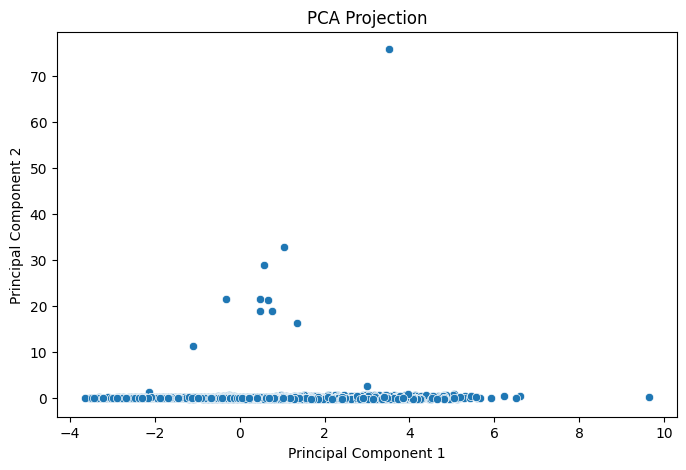

In [147]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=df_pca_result["PC1"],
    y=df_pca_result["PC2"]
)

plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

PCA was applied after standardizing the selected numerical features to reduce dimensionality while preserving key information.  
The first two components explain about 69% of the total variance (PC1 ≈ 49%, PC2 ≈ 20%), indicating that a significant portion of the dataset structure is retained.  
The projection shows most points concentrated along PC1 with a few outliers, suggesting that variation is mainly captured in one direction with some extreme property profiles.

answer to "When is feature engineering a nice-to-have option, and when is it a must-have?"

Feature engineering is a nice-to-have option when the dataset is already clean, well-structured, and the relationships between features and the target are simple and easily captured by basic models.  
It becomes a must-have when the data is complex, contains non-linear relationships, or lacks informative features, requiring transformation and creation of new variables to reveal hidden patterns.  
In real-world problems, feature engineering is often essential to improve model performance, reduce noise, and better represent the underlying structure of the data.